# UMAP plots

In [1]:
import random 
from random import sample, seed, shuffle
import numpy as np
import pandas as pd
import os
import six
from rdkit import rdBase
from rdkit import RDLogger


# Suppress RDKit warnings
rdBase.DisableLog('rdApp.*')
RDLogger.DisableLog('rdApp.*')

#utility functions : prepare the data 
from model_fp_selection.lib.utils import prepare_df_morgan, prepare_df_rdkit, swap_identical_ligands
from model_fp_selection.lib.utils import drop_duplicates, average_duplicates, calc_desc

#utility functions : CV and results 
from model_fp_selection.lib.utils import obtain_metrics, plot_cv_results
from model_fp_selection.lib.utils import df_split, get_indices, get_indices_doi, get_indices_scaff
from model_fp_selection.lib.utils import generate_scaffold, scaffold_to_smiles
from model_fp_selection.lib.utils import ligands_permutation, cross_validation, prepare_train_set


from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, Draw
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, median_absolute_error, PredictionErrorDisplay
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.preprocessing import MinMaxScaler

#Encoding categorical Data
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Regressors
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor

#Pipelines and other model constructions
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

# Visualization
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})

#np.random.seed(42)
#seed(42)

#Specific to Scaffold Splitting
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict
import pickle as pkl
import time
from tqdm import tqdm
import seaborn as sns

from itertools import *

In [2]:
import umap

In [3]:
os.environ['PYTHONHASHSEED'] = '0'   # only needed in extreme cases
np.random.seed(42)
mapper = umap.UMAP(
    n_neighbors=5,
    min_dist=0.1,
    metric='euclidean',
    random_state=42,   # essential for reproducibility
    init='spectral',   # good deterministic-ish init (still uses random_state)
    n_jobs=1           # single thread lowers nondeterminism (slower)
)

In [4]:
import re
def parse_array_string(s):
    if pd.isna(s):
        return np.array([])           # or return np.nan if you prefer
    # replace newlines and repeated whitespace with single space, remove brackets
    clean = re.sub(r"[\[\]\n]+", " ", str(s)).strip()
    if clean == "":
        return np.array([])
    return np.fromstring(clean, sep=" ")

In [5]:
metals= pd.read_csv("../ruthenium_complexes_dataset_charges.csv", dtype={'L1': str, 'L2': str, 'L3': str})
metals_rdkit = prepare_df_rdkit(metals, nbits=2048)

In [6]:
metals_morgan = prepare_df_morgan(metals, 2, 1024)

In [7]:
metals_rdkit = average_duplicates(metals_rdkit, 'Ligands_Tuple', 'pIC50')

Length of training dataset after cleaning duplicates, before adding permutations : 715


In [8]:
metals_morgan = average_duplicates(metals_morgan, 'Ligands_Tuple', 'pIC50')

Length of training dataset after cleaning duplicates, before adding permutations : 715


In [9]:
metals_desc = calc_desc(metals_rdkit)

In [10]:
synth = pd.read_csv('../synthesized_complexes_2.csv')

## Downloading the CSV files for 200 000 generated datapoints

**You can directly download the files from: xxxxxxxxxxxxxxxxxxxxxxx and place them in the "UMAP" file in order to run the notebook, or download it with the cell below:**

In [ ]:
### THIS CELL DOWNLOADS THE UMAP CSV FILES FROM FIGSHARE

from pathlib import Path
import requests

ARTICLE_ID = 31264441

BASE_DIR = Path("./data/UMAP")
BASE_DIR.mkdir(exist_ok=True)

api_url = f"https://api.figshare.com/v2/articles/{ARTICLE_ID}"
response = requests.get(api_url)
response.raise_for_status()
article = response.json()

umap_csv = ['dataset_encoded_to_Morgan_FP.csv', 'dataset_encoded_to_RDKit_FP.csv', 'generated_200k.csv']

for file_info in article["files"]:
    filename = file_info["name"]

    if filename in umap_csv :
        download_url = file_info["download_url"]

        local_path = BASE_DIR / filename
        local_path.parent.mkdir(parents=True, exist_ok=True)

        if local_path.exists():
            print(f"Skipping existing file: {filename}")
            continue

        print(f"Downloading: {filename}")
        with requests.get(download_url, stream=True) as r:
            r.raise_for_status()
            with open(local_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)

print("Done.")

## RDKit Descriptors

In [13]:
gen_desc = pd.read_csv('C:/Users/bparm/Documents/PhD/ml_ruthenium_complexes_tests/HP_opt_charges_dedup_env_chemeleon/To remove/UMAP/generated_200k.csv')

In [14]:
gen_desc['Descriptors'] = gen_desc['Descriptors'].apply(parse_array_string)

In [15]:
train_desc = metals_desc.copy()
df_umap_desc=[]

synth['IC50'] = [5.25, 4.20, 4.15, 6.08, 5.90, 4.30, 5.69]
synth_desc = prepare_df_rdkit(synth)
synth_desc = calc_desc(synth_desc)

train_desc['Descriptors'] = train_desc['Descriptors'].apply(lambda x: x.tolist())
train_desc['Dataset'] = 't'
train_desc = train_desc[['Descriptors', 'Dataset']]
df_umap_desc.append(train_desc)

synth_desc['Descriptors'] = synth_desc['Descriptors'].apply(lambda x: x.tolist())
synth_desc['Dataset'] = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
synth_desc = synth_desc[['Descriptors', 'Dataset']]
df_umap_desc.append(synth_desc)

gen_desc = gen_desc[['Descriptors']]
gen_desc['Dataset'] = 'g'
gen_desc = gen_desc[['Descriptors', 'Dataset']]
df_umap_desc.append(gen_desc)

total_df_desc = pd.concat(df_umap_desc, ignore_index=True, axis=0)

total_df_desc = total_df_desc.dropna(how='any')

print(f'length of total_df_desc : {len(total_df_desc)}')

scaler = StandardScaler()

X = np.array(total_df_desc['Descriptors'].tolist())

X = scaler.fit_transform(X)

X = X[~np.isnan(X).any(axis=1)]


print(f'lenght of X : {len(X)}')
print(f'shape of X : {X.shape}')

X_umap = mapper.fit_transform(X)
X_umap = pd.DataFrame(X_umap)

X_umap.columns = ['UMAP1', 'UMAP2']

X_umap['Dataset'] = total_df_desc['Dataset']
print(f'length of X_umap : {len(X_umap)}')

X_umap_gen = X_umap[X_umap['Dataset'] == 'g']
X_umap_train = X_umap[X_umap['Dataset'] == 't']
X_umap_synth = X_umap[X_umap['Dataset'].isin(['A', 'B', 'C', 'D', 'E', 'F', 'G'])]

length of total_df_desc : 200722
lenght of X : 200687
shape of X : (200687, 600)


C:\Users\bparm\anaconda3\envs\umap_explicit\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
C:\Users\bparm\anaconda3\envs\umap_explicit\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\bparm\anaconda3\envs\umap_explicit\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\bparm\anaconda3\envs\umap_explicit\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due t

length of X_umap : 200687


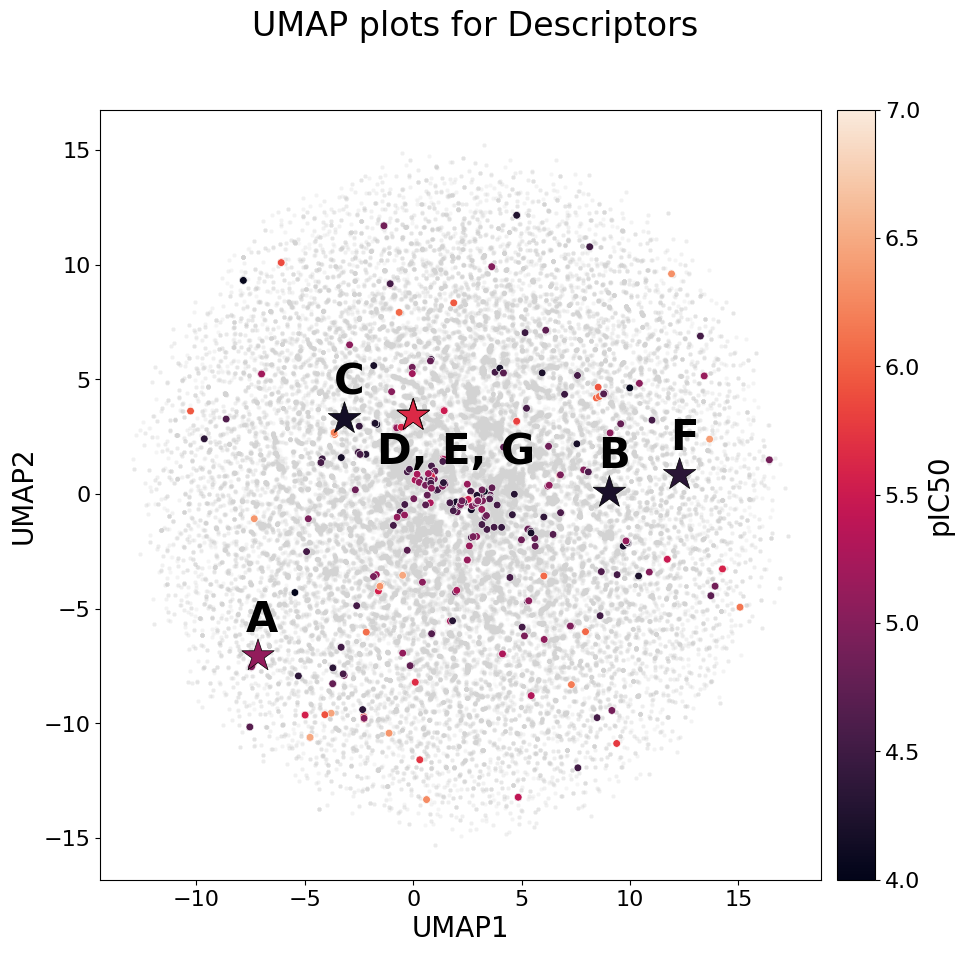

In [16]:
import matplotlib
fig, axes = plt.subplots(1, 1, figsize=(10, 10))

synth['IC50'] = [5.09, 4.20, 4.16, 5.97, 5.92, 4.33, 5.65]

fig.suptitle('UMAP plots for Descriptors')
cmap = sns.color_palette('rocket', as_cmap=True)

letters = ['A', 'B', 'C', 'D, E, G', '', 'F', '']

for (x, y), label in zip(X_umap_synth[['UMAP1','UMAP2']].values, letters):
    if label == 'D, E, G':
        axes.text(
            x+2,
            y-1.6,
            label,
            fontsize=30,
            fontweight='bold',
            ha='center',
            va='center',
            color='black',
            zorder=10
        )
    else:
        axes.text(
            x+0.2,
            y+1.6,
            label,
            fontsize=30,
            fontweight='bold',
            ha='center',
            va='center',
            color='black',
            zorder=10
        )


sns.scatterplot(ax=axes, data=X_umap_gen, x='UMAP1', y='UMAP2', s=8, alpha=0.05, color='lightgray', legend=False)
sns.scatterplot(ax=axes, data=X_umap_train, x='UMAP1', y='UMAP2', hue=metals_rdkit['pIC50'], palette=cmap, legend=False, s=30)
sns.scatterplot(ax=axes, data = X_umap_synth, x='UMAP1', y='UMAP2', marker='*', s=600, edgecolor='black', linewidth=0.5, hue=synth['IC50'].tolist(), palette=cmap, hue_norm=(4,7), legend=False)

#plt.xlim(-20,20)
#plt.ylim(-20,20)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=matplotlib.colors.Normalize(vmin=4, vmax=7))
sm.set_array([])  # required for colorbar
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.05, pad=0.02)
cbar.set_label('pIC50')

#plt.savefig('UMAP_200k_descriptors.png', dpi=300)

## Morgan fingerprints

In [ ]:
import json
gen_morgan = pd.read_csv('./UMAP/dataset_encoded_to_Morgan_FP.csv')
gen_morgan['Fingerprint'] = gen_morgan['Fingerprint'].apply(json.loads)
train_morgan = metals_morgan.copy()

In [ ]:
df_umap_morgan=[]

synth['IC50'] = [5.25, 4.20, 4.15, 6.08, 5.90, 4.30, 5.69]
synth_morgan = prepare_df_morgan(synth, 2, 1024)

train_morgan['Dataset'] = 't'
train_morgan = train_morgan[['Fingerprint', 'Dataset']]
df_umap_morgan.append(train_morgan)

synth_morgan['Dataset'] = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
synth_morgan = synth_morgan[['Fingerprint', 'Dataset']]
df_umap_morgan.append(synth_morgan)

gen_morgan = gen_morgan[['Fingerprint']]
gen_morgan['Dataset'] = 'g'
gen_morgan = gen_morgan[['Fingerprint', 'Dataset']]
df_umap_morgan.append(gen_morgan)

total_df_morgan = pd.concat(df_umap_morgan, ignore_index=True, axis=0)

print(f'length of total_df : {len(total_df_morgan)}')
X = total_df_morgan['Fingerprint']

X= X.tolist()
X = np.array(X, dtype=np.float32)
scaler = StandardScaler()
print(f'length of X : {len(X)}')
print(f'shape of X : {X.shape}')

X_umap = mapper.fit_transform(X)
X_umap = pd.DataFrame(X_umap)

X_umap.columns = ['UMAP1', 'UMAP2']

X_umap['Dataset'] = total_df_morgan['Dataset']
print(f'length of X_umap : {len(X_umap)}')

In [ ]:
X_umap_gen_morgan = X_umap[X_umap['Dataset'] == 'g']
X_umap_train_morgan = X_umap[X_umap['Dataset'] == 't']
X_umap_synth_morgan = X_umap[X_umap['Dataset'].isin(['A', 'B', 'C', 'D', 'E', 'F', 'G'])]

In [ ]:
import matplotlib

fig, axes = plt.subplots(1, 1, figsize=(10, 10))

fig.suptitle('UMAP plot for Morgan fingerprints')
cmap = sns.color_palette('rocket', as_cmap=True)

letters = ['A', 'B', 'C', '', 'D, E', 'F', 'G']

i=0
for (x, y), label in zip(X_umap_synth_morgan[['UMAP1','UMAP2']].values, letters):
        if label=='D, E':
            axes.text(x+0.8, y+0.8, label, fontsize=30, fontweight='bold', ha='left', va='center', color='black', zorder=10)
        else:
            axes.text(x+0.8, y-0.1, label, fontsize=30, fontweight='bold', ha='left', va='center', color='black', zorder=10)
        i+=1


sns.scatterplot(ax=axes, data=X_umap_gen_morgan, x='UMAP1', y='UMAP2', s=8, alpha=0.05, color='lightgray', legend=False)
sns.scatterplot(ax=axes, data=X_umap_train_morgan, x='UMAP1', y='UMAP2', hue=metals_rdkit['pIC50'], palette=cmap, legend=False, s=30)
sns.scatterplot(ax=axes, data = X_umap_synth_morgan, x='UMAP1', y='UMAP2', marker='*', s=600, edgecolor='black', linewidth=0.5 , hue=synth['IC50'].tolist(), palette=cmap, hue_norm=(4,7), legend=False)

#plt.xlim(-20,20)
#plt.ylim(-20,20)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=matplotlib.colors.Normalize(vmin=4, vmax=7))

sm.set_array([])  # required for colorbar
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.05, pad=0.02)
cbar.set_label('pIC50')

#plt.savefig('UMAP_200k_morgan.png', dpi=300)

## RDKit fingerprints

In [16]:
import json
gen_rdkit = pd.read_csv('C:/Users/bparm/Documents/PhD/ml_ruthenium_complexes_tests/HP_opt_charges_dedup_env_chemeleon/UMAP/dataset_encoded_to_RDKit_FP.csv')
gen_rdkit['Fingerprint'] = gen_rdkit['Fingerprint'].apply(json.loads)

In [17]:
train_rdkit = metals_rdkit.copy()

df_umap_rdkit=[]

synth['IC50'] = [5.16, 4.70, 4.33, 5.90, 5.73, 4.52, 5.47]
synth_rdkit = prepare_df_rdkit(synth)

train_rdkit['Dataset'] = 't'
train_rdkit = train_rdkit[['Fingerprint', 'Dataset']]
df_umap_rdkit.append(train_rdkit)

synth_rdkit['Dataset'] = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
synth_rdkit = synth_rdkit[['Fingerprint', 'Dataset']]
df_umap_rdkit.append(synth_rdkit)

gen_rdkit = gen_rdkit[['Fingerprint']]
gen_rdkit['Dataset'] = 'g'
gen_rdkit = gen_rdkit[['Fingerprint', 'Dataset']]
df_umap_rdkit.append(gen_rdkit)

total_df_rdkit = pd.concat(df_umap_rdkit, ignore_index=True, axis=0)

print(f'length of total_df : {len(total_df_rdkit)}')
scaler = StandardScaler()

X = np.array(total_df_rdkit['Fingerprint'].tolist())
print(f'length of X : {len(X)}')
print(f'shape of X : {X.shape}')

X_umap = mapper.fit_transform(X)
X_umap = pd.DataFrame(X_umap)

X_umap.columns = ['UMAP1', 'UMAP2']

X_umap['Dataset'] = total_df_rdkit['Dataset']
print(f'length of X_umap : {len(X_umap)}')

length of total_df : 186795
length of X : 186795
shape of X : (186795, 2048)


C:\Users\bparm\anaconda3\envs\ml_ru_chemeleon\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
C:\Users\bparm\anaconda3\envs\ml_ru_chemeleon\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:453: UserWarning: Exited at iteration 466 with accuracies 
[2.04693871e-05 5.91999292e-05 1.59238372e-05 5.14615778e-04]
not reaching the requested tolerance 1.6748905181884766e-05.
Use iteration 430 instead with accuracy 
8.244360380099513e-05.

  _, diffusion_map = lobpcg(
C:\Users\bparm\anaconda3\envs\ml_ru_chemeleon\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:453: UserWarning: Exited postprocessing with accuracies 
[1.54382160e-05 2.47240849e-05 2.19115464e-05 2.67700570e-04]
not reaching the requested tolerance 1.6748905181884766e-05.
  _, diffusion_map = lobpcg(


length of X_umap : 186795


In [18]:
X_umap_gen_rdkit = X_umap[X_umap['Dataset'] == 'g']
X_umap_train_rdkit = X_umap[X_umap['Dataset'] == 't']
X_umap_synth_rdkit = X_umap[X_umap['Dataset'].isin(['A', 'B', 'C', 'D', 'E', 'F', 'G'])]

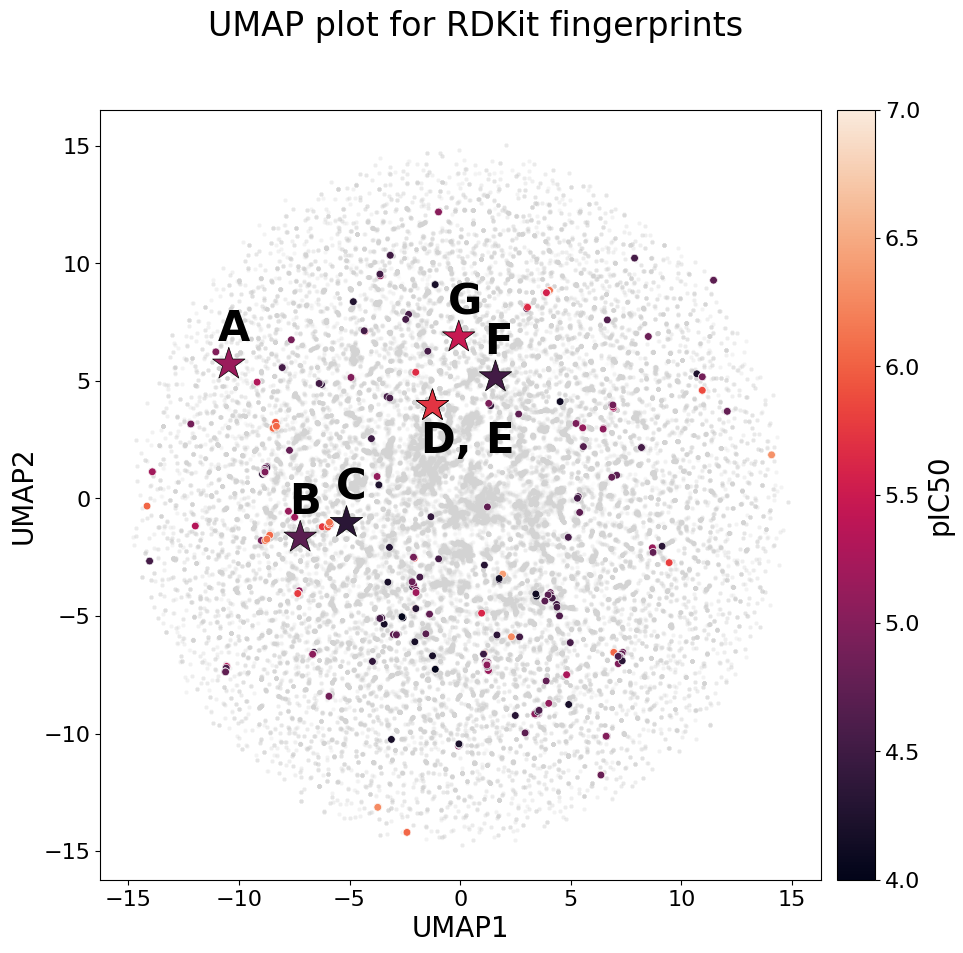

In [19]:
import matplotlib

fig, axes = plt.subplots(1, 1, figsize=(10, 10))

fig.suptitle('UMAP plot for RDKit fingerprints')
cmap = sns.color_palette('rocket', as_cmap=True)

letters = ['A', 'B', 'C', 'D, E', '', 'F', 'G']

for (x, y), label in zip(X_umap_synth_rdkit[['UMAP1','UMAP2']].values, letters):
    if label=='D, E':
        axes.text(
        x-0.5,
        y-1.5,
        label,
        fontsize=30,
        fontweight='bold',
        ha='left',
        va='center',
        color='black',      # choose your color
        zorder=10
    )
    else:
        axes.text(
            x-0.5,
            y+1.5,
            label,
            fontsize=30,
            fontweight='bold',
            ha='left',
            va='center',
            color='black',      # choose your color
            zorder=10
        )


sns.scatterplot(ax=axes, data=X_umap_gen_rdkit, x='UMAP1', y='UMAP2', s=8, alpha=0.05, color='lightgray', legend=False)
sns.scatterplot(ax=axes, data=X_umap_train_rdkit, x='UMAP1', y='UMAP2', hue=metals_rdkit['pIC50'], palette=cmap, legend=False, s=30)
sns.scatterplot(ax=axes, data = X_umap_synth_rdkit, x='UMAP1', y='UMAP2', marker='*', s=600, edgecolor='black', linewidth=0.5, hue=synth['IC50'].tolist(), palette=cmap, hue_norm=(4,7), legend=False)

#plt.xlim(-20,20)
#plt.ylim(-20,20)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=matplotlib.colors.Normalize(vmin=4, vmax=7))

sm.set_array([])  # required for colorbar
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.05, pad=0.02)
cbar.set_label('pIC50')

#plt.savefig('UMAP_200k_rdkit.png', dpi=300)

## CheMeleon finetuned representation

To keep the notebook resource-friendly, the representations and UMAP projections were calculated on a GPU cluster.

In [ ]:
X_umap_train_chemeleon = pd.read_csv('./UMAP/X_umap_train_chemeleon.csv')

In [ ]:
X_umap_synth_chemeleon = pd.read_csv('./UMAP/X_umap_synth_chemeleon.csv')

In [ ]:
X_umap_gen_chemeleon = pd.read_csv('./UMAP/X_umap_gen_chemeleon.csv')

In [ ]:
synth_chemeleon['IC50'] = [5.68, 4.66, 4.13, 6.36, 6.18, 4.58, 5.57]

In [ ]:
import matplotlib

fig, axes = plt.subplots(1, 1, figsize=(10, 10))

fig.suptitle('UMAP plot for Chemeleon')
cmap = sns.color_palette('rocket', as_cmap=True)

letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

for (x, y), label in zip(X_umap_synth_chemeleon[['UMAP1','UMAP2']].values, letters):
    if label == 'E':
        axes.text(
            x+0.8,
            y,
            label,
            fontsize=30,
            fontweight='bold',
            ha='left',
            va='center',
            color='black',      # choose your color
            zorder=10
        )

    else:
        axes.text(
            x-2.3,
            y,
            label,
            fontsize=30,
            fontweight='bold',
            ha='left',
            va='center',
            color='black',      # choose your color
            zorder=10
        )

sns.scatterplot(ax=axes, data=X_umap_gen_chemeleon, x='UMAP1', y='UMAP2', s=8, alpha=0.05, color='lightgray', legend=False)
sns.scatterplot(ax=axes, data=X_umap_train_chemeleon, x='UMAP1', y='UMAP2', hue=metals_rdkit['pIC50'].tolist(), palette=cmap, legend=False, s=30)
sns.scatterplot(ax=axes, data = X_umap_synth_chemeleon, x='UMAP1', y='UMAP2', marker='*', s=600, edgecolor='black', linewidth=0.5, hue=synth_chemeleon['IC50'].tolist(), palette=cmap, hue_norm=(4,7), legend=False)

#plt.xlim(-20,20)
#plt.ylim(-20,20)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=matplotlib.colors.Normalize(vmin=4, vmax=7))

sm.set_array([])  # required for colorbar
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.05, pad=0.02)
cbar.set_label('pIC50')

#plt.savefig('UMAP_200k_chemeleon_gnn.png', dpi=300)